In [3]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df["average_score"] = (
    df["math score"] + df["reading score"] + df["writing score"]
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


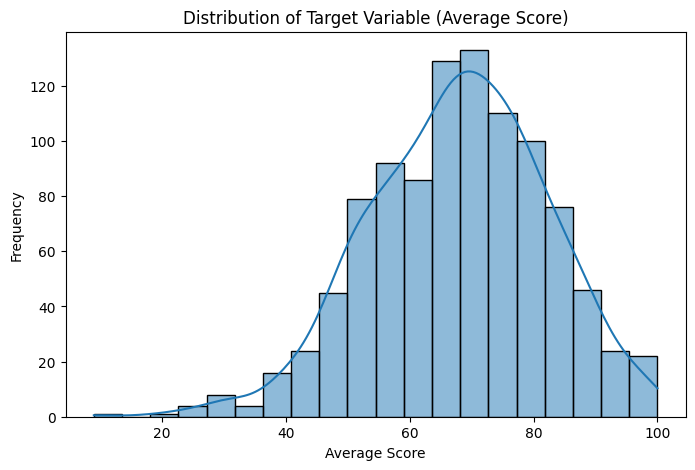

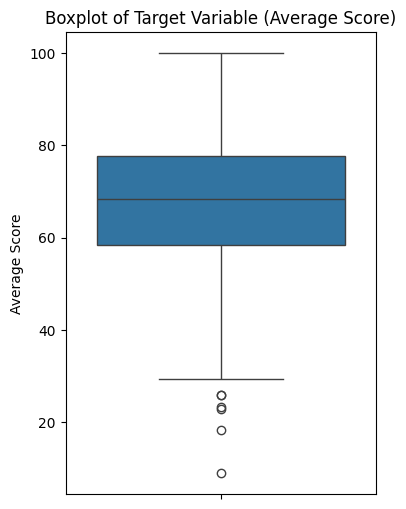

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["average_score"], kde=True, bins=20)
plt.title("Distribution of Target Variable (Average Score)")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(4,6))
sns.boxplot(y=df["average_score"])
plt.title("Boxplot of Target Variable (Average Score)")
plt.ylabel("Average Score")
plt.show()

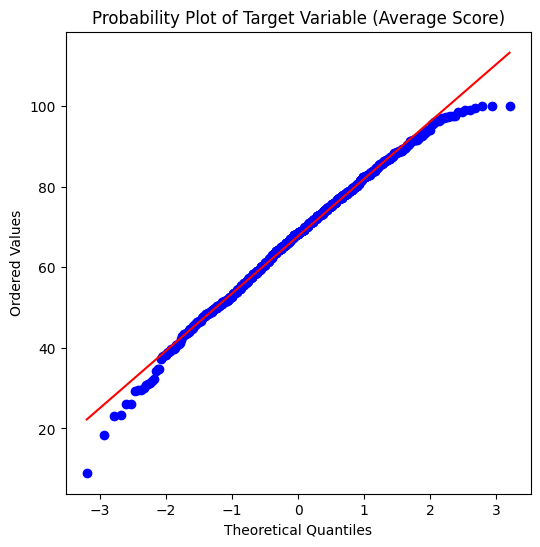

In [10]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(df["average_score"], dist="norm", plot=plt)

plt.title("Probability Plot of Target Variable (Average Score)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values")
plt.show()

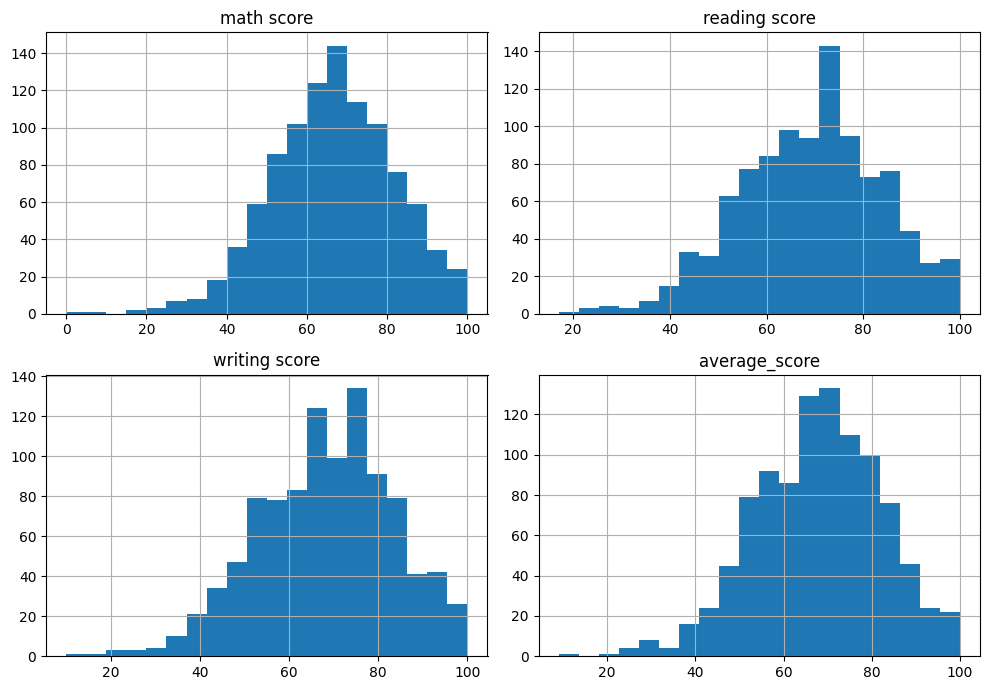

In [12]:
import matplotlib.pyplot as plt

numerical_columns = [
    "math score",
    "reading score",
    "writing score",
    "average_score"
]

df[numerical_columns].hist(
    bins=20,
    figsize=(10, 7),
    grid=True
)

plt.tight_layout()
plt.show()

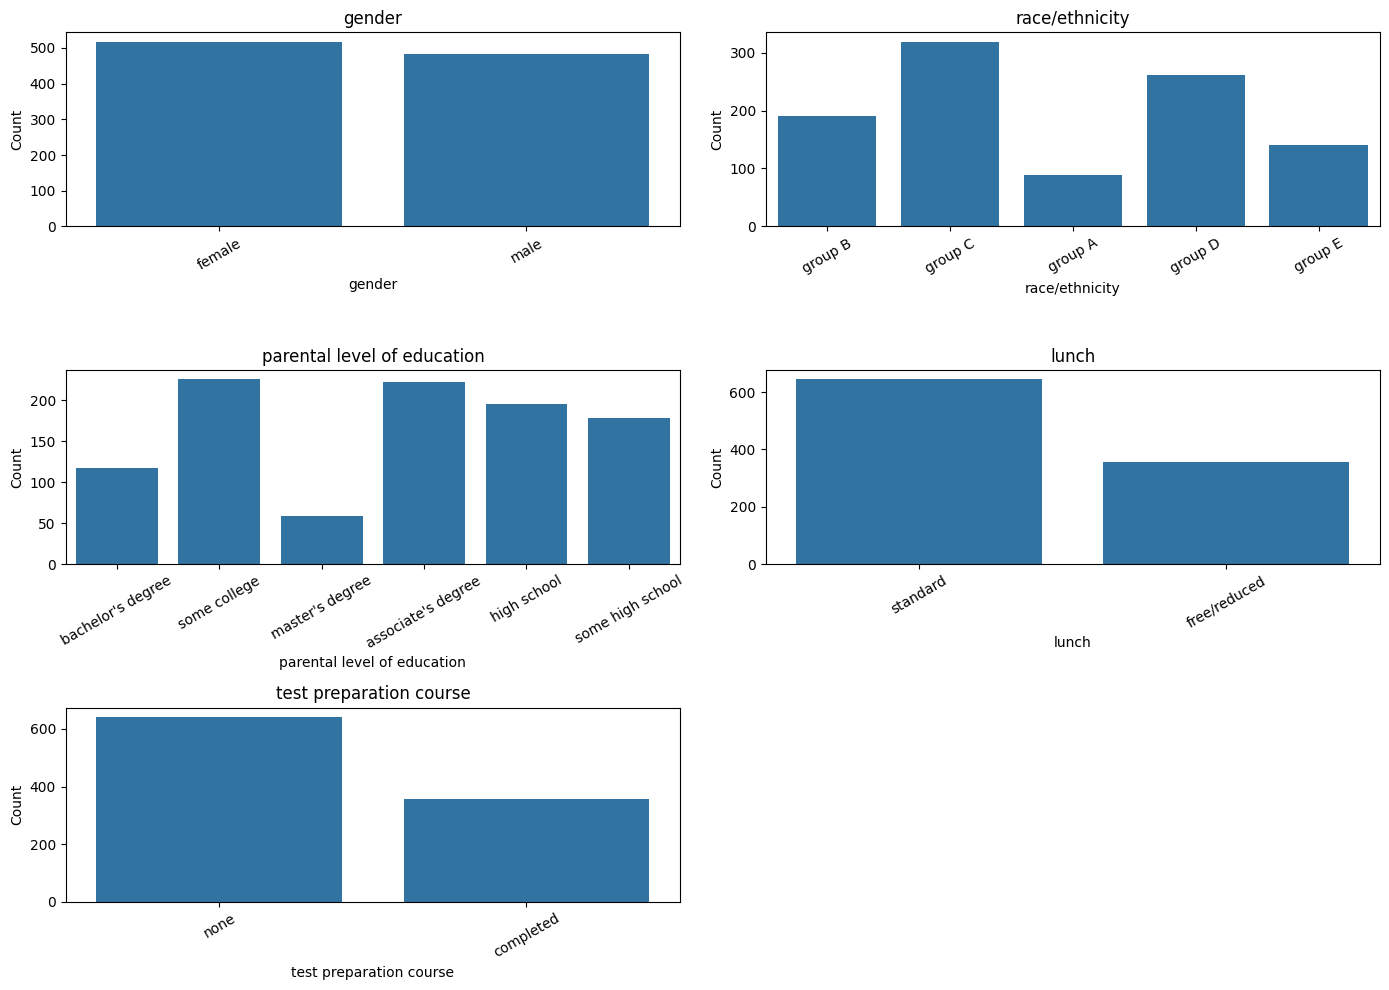

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

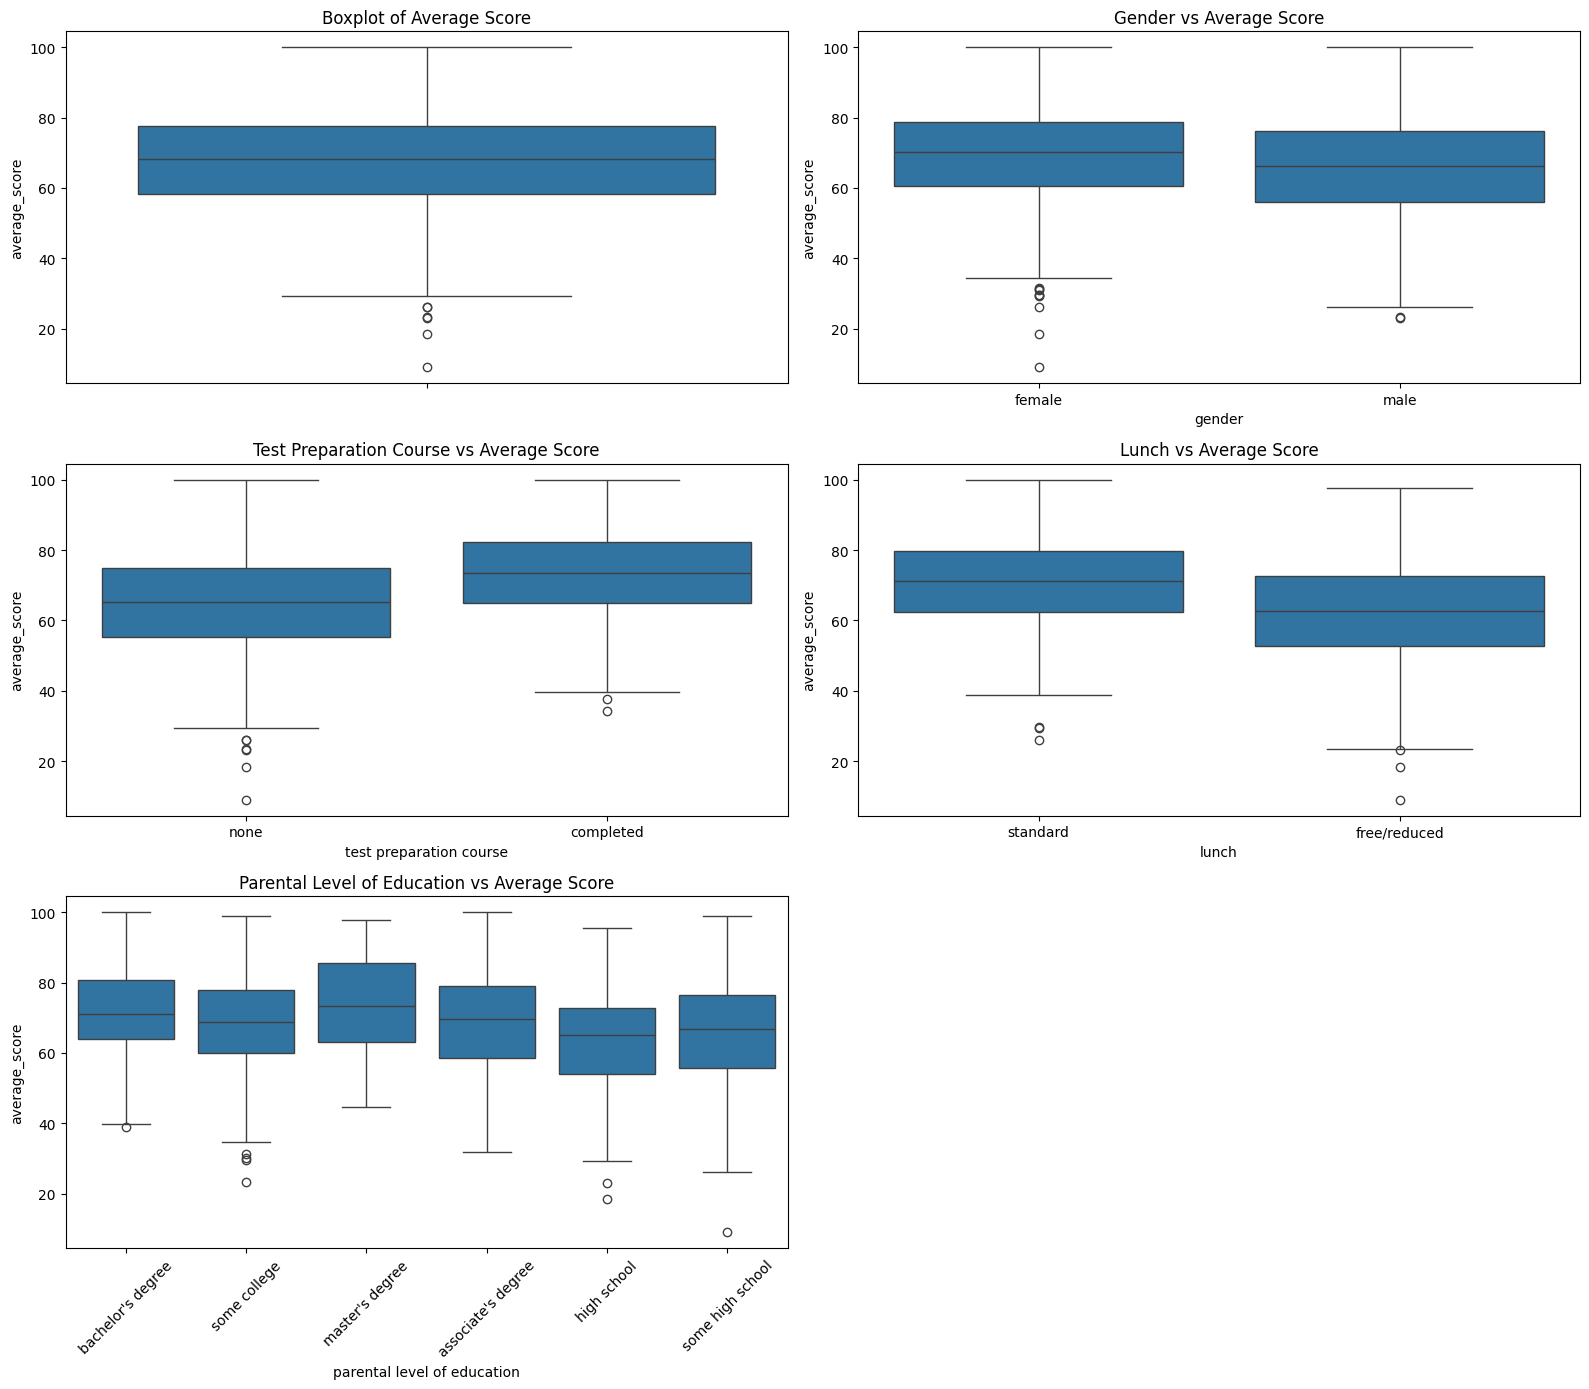

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 14))

plt.subplot(3, 2, 1)
sns.boxplot(y=df["average_score"])
plt.title("Boxplot of Average Score")
plt.ylabel("average_score")

plt.subplot(3, 2, 2)
sns.boxplot(data=df, x="gender", y="average_score")
plt.title("Gender vs Average Score")

plt.subplot(3, 2, 3)
sns.boxplot(data=df, x="test preparation course", y="average_score")
plt.title("Test Preparation Course vs Average Score")

plt.subplot(3, 2, 4)
sns.boxplot(data=df, x="lunch", y="average_score")
plt.title("Lunch vs Average Score")

plt.subplot(3, 2, 5)
sns.boxplot(data=df, x="parental level of education", y="average_score")
plt.title("Parental Level of Education vs Average Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

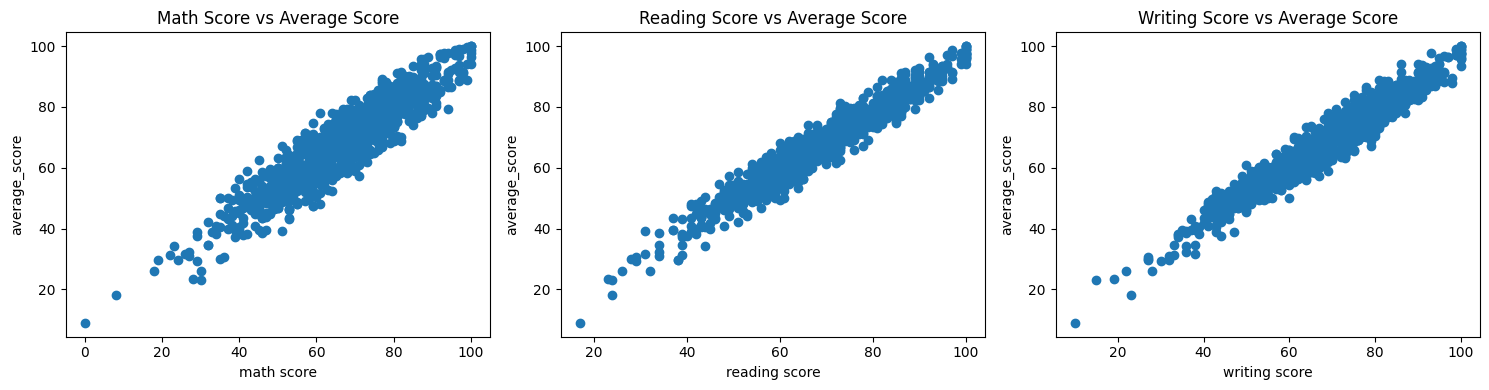

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(df["math score"], df["average_score"])
plt.title("Math Score vs Average Score")
plt.xlabel("math score")
plt.ylabel("average_score")

plt.subplot(1, 3, 2)
plt.scatter(df["reading score"], df["average_score"])
plt.title("Reading Score vs Average Score")
plt.xlabel("reading score")
plt.ylabel("average_score")

plt.subplot(1, 3, 3)
plt.scatter(df["writing score"], df["average_score"])
plt.title("Writing Score vs Average Score")
plt.xlabel("writing score")
plt.ylabel("average_score")

plt.tight_layout()
plt.show()

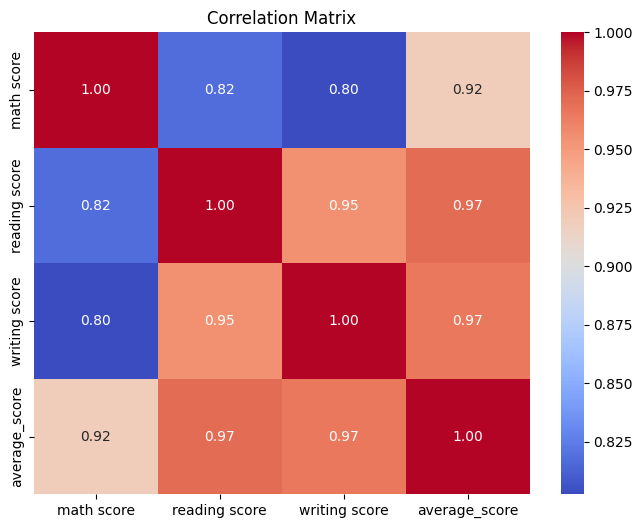

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = [
    "math score",
    "reading score",
    "writing score",
    "average_score"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [18]:
X = df.drop(columns=["math score", "reading score", "writing score", "average_score"])
y = df["average_score"]
print("X Shape", X.shape)
print("Y Shape", y.shape)

X Shape (1000, 5)
Y Shape (1000,)


In [19]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.astype(int)
X_encoded.head()

,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,0,1,0,0,0,1,0,0,0,0,1,1
1,0,0,1,0,0,0,0,0,1,0,1,0
2,0,1,0,0,0,0,0,1,0,0,1,1
3,1,0,0,0,0,0,0,0,0,0,0,1
4,1,0,1,0,0,0,0,0,1,0,1,1


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 12)
X_test shape: (200, 12)
y_train shape: (800,)
y_test shape: (200,)


In [21]:
print("Training features:")
print(X_train.head())

print("\nTraining target:")
print(y_train.head())

Training features:
     gender_male  race/ethnicity_group B  race/ethnicity_group C  \
29             0                       0                       0   
535            0                       0                       1   
695            0                       0                       0   
557            1                       0                       1   
836            1                       0                       0   

     race/ethnicity_group D  race/ethnicity_group E  \
29                        1                       0   
535                       0                       0   
695                       1                       0   
557                       0                       0   
836                       0                       1   

     parental level of education_bachelor's degree  \
29                                               0   
535                                              1   
695                                              0   
557                      

In [22]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("Missing values in X_test:")
print(X_test.isnull().sum().sum())

print("Missing values in y_train:")
print(y_train.isnull().sum())

print("Missing values in y_test:")
print(y_test.isnull().sum())

Missing values in X_train:
0
Missing values in X_test:
0
Missing values in y_train:
0
Missing values in y_test:
0


In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)
y_pred[:10]

array([70.52277256, 67.2809476 , 72.79594181, 56.36915946, 78.49679002,
       60.08618529, 64.04319512, 74.06970937, 57.22326239, 69.97785396])

In [26]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,87.000000,70.522773
1,64.000000,67.280948
2,75.000000,72.795942
3,74.666667,56.369159
4,81.666667,78.496790
5,78.000000,60.086185
6,67.333333,64.043195
7,59.000000,74.069709
8,77.333333,57.223262
9,48.666667,69.977854


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 10.490182374209294
MSE: 179.60234233623538
RMSE: 13.401579844788277
R2 Score: 0.16217185763155217


In [28]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

ridge_y_pred = ridge_model.predict(X_test)
ridge_y_pred[:10]

array([70.50235325, 67.28390623, 72.74342037, 56.42768765, 78.42313265,
       60.10693456, 64.04032619, 74.03293703, 57.26380652, 69.95323813])

In [29]:
ridge_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Ridge Predicted": ridge_y_pred
})

ridge_comparison.head(10)

,Actual,Ridge Predicted
0,87.000000,70.502353
1,64.000000,67.283906
2,75.000000,72.743420
3,74.666667,56.427688
4,81.666667,78.423133
5,78.000000,60.106935
6,67.333333,64.040326
7,59.000000,74.032937
8,77.333333,57.263807
9,48.666667,69.953238


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_mse = mean_squared_error(y_test, ridge_y_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_y_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2 Score:", ridge_r2)

Ridge MAE: 10.495994452715388
Ridge MSE: 179.74180175083148
Ridge RMSE: 13.406781931203009
Ridge R2 Score: 0.16152129249555802


In [31]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()
lasso_model.fit(X_train, y_train)

lasso_y_pred = lasso_model.predict(X_test)
lasso_y_pred[:10]

array([68.55177258, 67.65805884, 68.37736802, 63.69700214, 72.16402017,
       63.69700214, 67.48365428, 72.33842473, 63.69700214, 72.16402017])

In [32]:
lasso_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Lasso Predicted": lasso_y_pred
})

lasso_comparison.head(10)

,Actual,Lasso Predicted
0,87.000000,68.551773
1,64.000000,67.658059
2,75.000000,68.377368
3,74.666667,63.697002
4,81.666667,72.164020
5,78.000000,63.697002
6,67.333333,67.483654
7,59.000000,72.338425
8,77.333333,63.697002
9,48.666667,72.164020


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lasso_mae = mean_absolute_error(y_test, lasso_y_pred)
lasso_mse = mean_squared_error(y_test, lasso_y_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_y_pred)

print("Lasso MAE:", lasso_mae)
print("Lasso MSE:", lasso_mse)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R2 Score:", lasso_r2)

Lasso MAE: 11.088571930238363
Lasso MSE: 199.76391545455235
Lasso RMSE: 14.133786309922488
Lasso R2 Score: 0.06812000322242895


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [35]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 11.480718162177617
Random Forest MSE: 218.356827755504
Random Forest RMSE: 14.776901832099448
Random Forest R2 Score: -0.01861419507194917


In [38]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [39]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree MAE: 11.880278018278018
Decision Tree MSE: 232.64190452863636
Decision Tree RMSE: 15.2526032049823
Decision Tree R2 Score: -0.08525274321525722


In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 12.63635907979618


In [43]:
best_rf_model = grid_search.best_estimator_

best_rf_pred = best_rf_model.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_mse = mean_squared_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(best_rf_mse)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest MAE:", best_rf_mae)
print("Tuned Random Forest MSE:", best_rf_mse)
print("Tuned Random Forest RMSE:", best_rf_rmse)
print("Tuned Random Forest R2 Score:", best_rf_r2)

Tuned Random Forest MAE: 10.86618594043075
Tuned Random Forest MSE: 193.95552959851597
Tuned Random Forest RMSE: 13.926791791310588
Tuned Random Forest R2 Score: 0.09521558042159273


In [44]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_y_pred = xgb_model.predict(X_test)
xgb_y_pred[:10]

array([68.994316, 73.93694 , 63.874977, 56.31803 , 79.2761  , 59.273155,
       69.39935 , 70.794876, 59.721764, 70.67131 ], dtype=float32)

In [45]:
xgb_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "XGBoost Predicted": xgb_y_pred
})

xgb_comparison.head(10)

,Actual,XGBoost Predicted
0,87.000000,68.994316
1,64.000000,73.936943
2,75.000000,63.874977
3,74.666667,56.318031
4,81.666667,79.276100
5,78.000000,59.273155
6,67.333333,69.399353
7,59.000000,70.794876
8,77.333333,59.721764
9,48.666667,70.671310


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2 Score:", xgb_r2)

XGBoost MAE: 11.020780220031739
XGBoost MSE: 203.74180870838788
XGBoost RMSE: 14.273815492305758
XGBoost R2 Score: 0.0495635029449345


In [47]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Decision Tree",
        "Tuned Random Forest",
        "Ridge Regression",
        "Lasso Regression",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        dt_mae,
        best_rf_mae,
        ridge_mae,
        lasso_mae,
        xgb_mae
    ],
    "MSE": [
        mse,
        rf_mse,
        dt_mse,
        best_rf_mse,
        ridge_mse,
        lasso_mse,
        xgb_mse
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        dt_rmse,
        best_rf_rmse,
        ridge_rmse,
        lasso_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        r2,
        rf_r2,
        dt_r2,
        best_rf_r2,
        ridge_r2,
        lasso_r2,
        xgb_r2
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,10.490182,179.602342,13.401580,0.162172
1,Random Forest,11.480718,218.356828,14.776902,-0.018614
2,Decision Tree,11.880278,232.641905,15.252603,-0.085253
3,Tuned Random Forest,10.866186,193.955530,13.926792,0.095216
4,Ridge Regression,10.495994,179.741802,13.406782,0.161521
5,Lasso Regression,11.088572,199.763915,14.133786,0.068120
6,XGBoost,11.020780,203.741809,14.273815,0.049564


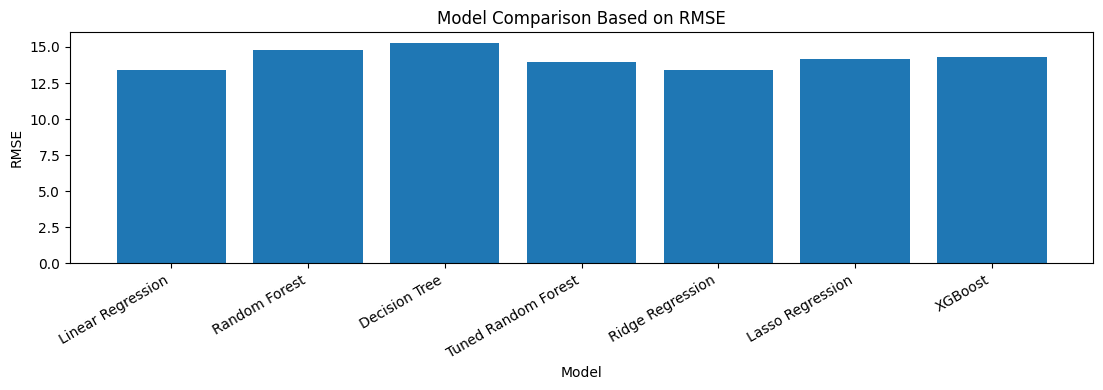

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,lunch_standard,0.407266
11,test preparation course_none,0.342154
0,gender_male,0.069153
6,parental level of education_high school,0.068635
5,parental level of education_bachelor's degree,0.025531
4,race/ethnicity_group E,0.025503
1,race/ethnicity_group B,0.015699
9,parental level of education_some high school,0.015120
3,race/ethnicity_group D,0.011174
7,parental level of education_master's degree,0.010913


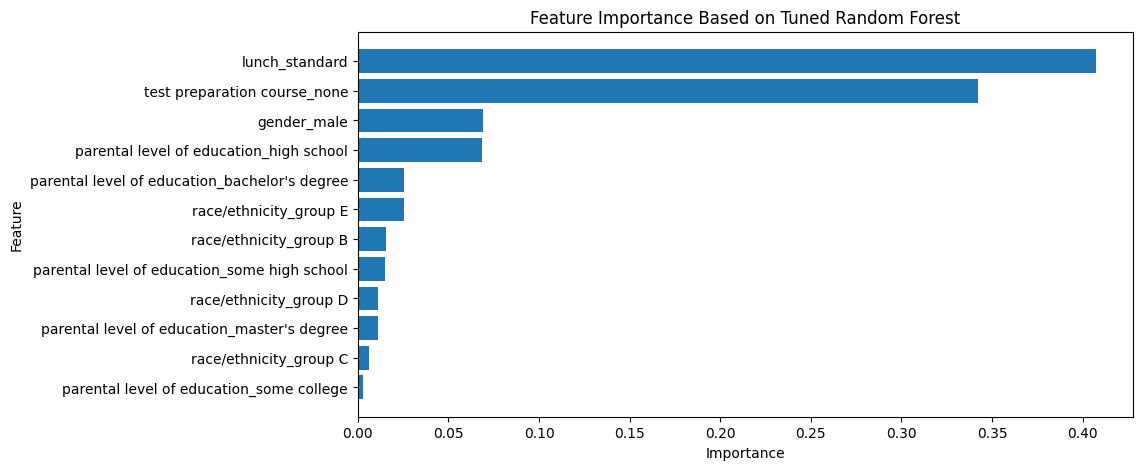

In [50]:
plt.figure(figsize=(10,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance Based on Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [51]:
comparison_all = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": y_pred,
    "Random Forest": rf_pred,
    "Decision Tree": dt_pred,
    "Tuned Random Forest": best_rf_pred,
    "Ridge Regression": ridge_y_pred,
    "Lasso Regression": lasso_y_pred,
    "XGBoost": xgb_y_pred
})

comparison_all.head(10)

,Actual,Linear Regression,Random Forest,Decision Tree,Tuned Random Forest,Ridge Regression,Lasso Regression,XGBoost
0,87.000000,70.522773,67.303618,66.733333,70.378289,70.502353,68.551773,68.994316
1,64.000000,67.280948,71.043222,70.000000,69.247485,67.283906,67.658059,73.936943
2,75.000000,72.795942,63.064921,62.000000,67.062500,72.743420,68.377368,63.874977
3,74.666667,56.369159,57.112103,56.466667,59.488454,56.427688,63.697002,56.318031
4,81.666667,78.496790,80.013861,80.111111,77.243252,78.423133,72.164020,79.276100
5,78.000000,60.086185,59.952968,60.000000,60.549022,60.106935,63.697002,59.273155
6,67.333333,64.043195,67.660579,67.000000,68.469877,64.040326,67.483654,69.399353
7,59.000000,74.069709,61.234778,61.333333,74.940887,74.032937,72.338425,70.794876
8,77.333333,57.223262,60.210272,59.833333,59.391089,57.263807,63.697002,59.721764
9,48.666667,69.977854,70.101074,70.733333,73.971478,69.953238,72.164020,70.671310
